# Run Reactive Transport Model

The first four notebooks focus on the **hydrology**: moving water from the air,
through the snow, soil, and groundwater stores, and out to the river as
streamflow. In this notebook we couple that water movement to the **chemistry**
in the water: we run a **reactive transport (RT) model**, which simulates how
dissolved chemicals are produced, consumed, and carried along as the water flows.

The specific system is a simple carbon cycle in the soil:

- **DOC** - dissolved organic carbon, the "dissolved" form of soil organic
  matter that the water carries with it (this is what we have concentration
  observations for).
- **SOC(s)** - soil organic carbon, a solid "mineral" that slowly decomposes
  over time (respires) and thereby produces DOC.

The single reaction is **respiration**: buried soil organic carbon `SOC(s)`
breaks down at a temperature- and soil-moisture-dependent rate, releasing DOC
into the water. As the water percolates down through the snow, surface,
shallow, and deep layers, it picks up DOC from the decomposition and carries it
to the river, where we can measure the concentration.

The steps in this notebook are:

1. Load the input data (both the weather forcing and the chemistry observations)
2. Set up the hydrologic model (unchanged from the hydrology notebooks - this is
   just the "plumbing" that moves the water)
3. Load and inspect the chemical reaction network
4. Define the per-zone reactive-transport parameters
5. Assemble the reactive transport model
6. Run the model (hydrology + chemistry together)
7. View the model outputs
8. Plot the results

This is a Jupytext-style percent script: code cells are delimited by `# %%` and
text cells by `# %% [markdown]`.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pandas import DataFrame, Series
from scipy import optimize

import potions as pt
from potions.reactive_transport.common_networks import get_simple_carbon_network

# The notebooks in this repo are expected to be run from the `scripts` directory,
# so the data lives one level up, in `../data`.
data_dir: str = "../data"
forcing_path: str = os.path.join(data_dir, "model_inputs", "forcing.csv")
measured_path: str = os.path.join(data_dir, "model_inputs", "measured_data.csv")

## 1. Load the input data

As before, we read the two CSV files written out by the first notebook:

- `model_inputs/forcing.csv` - the daily weather drivers: precipitation (`ppt`),
  air temperature (`temp`), and potential evapotranspiration (`pet`).
- `model_inputs/measured_data.csv` - the observations. It has two columns: the
  observed streamflow (`q_mmd`, mm/day) and the observed dissolved organic
  carbon concentration in the river (`doc_mol_l`, mol/L). The RT model needs
  **both**: the streamflow to compare the hydrology to, and the DOC
  concentration to compare the chemistry to.

In [2]:
forcing_df: DataFrame = pd.read_csv(forcing_path, index_col=0, parse_dates=True)
measured_df: DataFrame = pd.read_csv(measured_path, index_col=0, parse_dates=True)

print(
    f"Forcing spans {forcing_df.index[0].date()} to {forcing_df.index[-1].date()} ({len(forcing_df)} days)"
)
print(
    f"Meas. data spans {measured_df.index[0].date()} to {measured_df.index[-1].date()} ({len(measured_df)} days)"
)

measured_df.head()

Forcing spans 2008-10-01 to 2015-09-30 (2554 days)
Meas. data spans 2009-10-01 to 2015-09-30 (2191 days)


,q_mmd,doc_mol_l
2009-10-01,0.988387,NaN
2009-10-02,0.949048,NaN
2009-10-03,1.669440,NaN
2009-10-04,1.170329,NaN
2009-10-05,1.027726,NaN


## 2. Set up the hydrologic model

Reactive transport rides on top of the hydrology: the model first moves water
through the zones (exactly as in `2_Run_Hydrologic_Model.py`) and then advects
the dissolved chemicals along with that water. Here we re-use the same
four-zone `HbvModel` and the same tuned zones, because **the hydrology is not
the point of this notebook** - it is just the machinery that carries the
chemistry. We deliberately keep it simple.

In [3]:
# Bundle the three weather series into a single forcing data object.
forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"],
    temp=forcing_df["temp"],
    pet=forcing_df["pet"],
)

# The two observations: streamflow (mm/day) and DOC concentration (mol/L).
meas_streamflow: Series = measured_df["q_mmd"]

# The river-chemistry observations. `meas_river_conc` wants a DataFrame with one
# column per chemical species that we have measurements for; we only measure DOC.
meas_river_conc: DataFrame = measured_df["doc_mol_l"].to_frame("DOC")

# Custom hydrologic zone parameters, identical to notebook 2. Any zone we do not
# mention keeps its class defaults.
custom_zones: dict[str, pt.HydrologicZone] = {
    "snow": pt.SnowZone(tt=0.5, fmax=2.0),
    "surface": pt.SurfaceZone(fc=250.0, thr=25.0),
    "shallow": pt.SubsurfaceZone(k=2.0e-2, perc=0.5),
    # "deep" is left at its defaults.
}

hydro_model: pt.HbvModel = pt.HbvModel(zones=custom_zones)

print("Zones in the model (top to bottom):")
for zone_name in hydro_model.get_zone_names():
    print(f"  - {zone_name}: {hydro_model[zone_name].__class__.__name__}")
print(f"Number of surface zones (forcing series): {hydro_model.num_surface_zones}")

Zones in the model (top to bottom):
  - snow: SnowZone
  - surface: SurfaceZone
  - shallow: GroundZone
  - deep: GroundZoneB
Number of surface zones (forcing series): 1


## 3. Load and inspect the chemical reaction network

The chemistry is described by a **reaction network**, which tells the model:

- which **aqueous species** are dissolved in the water (here, `DOC`),
- which **solids** ("minerals") react in the soil (here, `SOC(s)`) and the
  reaction kinetics (how fast each one reacts),
- which **secondary** species are produced at equilibrium (none here),
- which species can be **exchanged** onto a sorption site (none here).

`potions` ships a library of common networks. For this notebook we use the
simplest carbon network, which we import from
`potions.reactive_transport.common_networks`. (In the next notebook we build a
network from scratch instead of using this helper.)

In [4]:
# The simple carbon reaction network: one dissolved species (DOC) produced by the
# respiration of one solid (SOC(s)).
network: pt.ReactionNetwork = get_simple_carbon_network()

print("Dissolved/aqueous + solid species in the network:", network.species_names)
print(
    f"Total number of species: {network.num_species} "
    f"({network.num_aqueous_species} dissolved, {network.num_minerals} solid)"
)
print(f"Solid species: {list(network.mineral_names)}")
print(f"Each solid carries {network.num_mineral_parameters} tunable parameters")
print(f"Has exchange (sorption) species? {network.has_exchange}")

Dissolved/aqueous + solid species in the network: ['DOC', 'SOC(s)']
Total number of species: 2 (1 dissolved, 1 solid)
Solid species: ['SOC(s)']
Each solid carries 5 tunable parameters
Has exchange (sorption) species? False


## 4. Define the per-zone reactive-transport parameters

Each soil layer needs its own RT parameters. These describe the **physical
space** the chemistry happens in and **how the minerals in that layer behave**.
There are three ingredients:

1. **`ZoneDimensions`** - the size and porosity of the water-holding zone
   (porosity, depth, and any water that is too tightly bound to move). The
   same physical zone is used for every layer here.
2. **`MineralAuxParams`** - one set per solid, tuning *how much* of that solid
   reacts in this layer. The key parameter is `ssa` (specific surface area,
   g/mol of mineral): a larger surface area exposes more of the solid to
   reaction, so more DOC is produced. The other factors gate the reaction on
   soil moisture (`sw_threshold`, `sw_exp`) and temperature (`q_10`).
3. **`RtParameters`** - bundles the dimensions with the (optional) mineral
   parameters for one zone. A zone with no solids (like the snow pack) sets
   `mineral_params=None`.

Finally we wrap each parameter set and the reaction network together in an
**`RtZone`**. One `RtZone` is needed for **every zone in the hydrologic model**
(including the inactive snow layer), and they are handed to the model in a
dictionary keyed by zone name.

In [5]:
# Shared physical dimensions for every reacting layer.
zone_dimensions: pt.ZoneDimensions = pt.ZoneDimensions(
    porosity=0.5,  # fraction of the layer volume that holds water
    depth=2_500.0,  # depth of the reactive zone, mm
    passive_water_storage=0.0,  # water that does not participate in streamflow
)


def mineral_params_from_ssa(ssa: float, q10: float = 1.5) -> pt.MineralParameters:
    """Build the mineral parameters for a layer from a single surface-area value.

    Wraps one `MineralAuxParams` (for the one solid `SOC(s)` in the network) into
    a `MineralParameters` object. Larger `ssa` -> more surface area -> faster
    respiration -> more DOC produced in that layer.
    """
    auxiliary: pt.MineralAuxParams = pt.MineralAuxParams(
        ssa=ssa,
        sw_threshold=0.5,  # soil moisture below this, reactions are inhibited
        sw_exp=1.0,  # soil water nonlinearity
        q_10=q10,  # rate multiplier per 10 deg C of warming
    )
    return pt.MineralParameters.from_mineral_parameters([auxiliary])


# A dictionary of RtZone objects, one per hydrologic zone, keyed by zone name.
# The top-of-snow layer has no solids, so it simply does not react.
rt_zones: dict[str, pt.RtZone] = {
    "snow": pt.RtZone(
        network,
        pt.RtParameters(dimensions=zone_dimensions, mineral_params=None),
        do_reactions=False,
        do_speciation=False,
        name="snow",
    ),
    # Lower layers react, and we assume the surface holds the most reactive
    # soil organic matter, less in the shallow store, and still less in the deep
    # store (the surface area drops with depth).
    "surface": pt.RtZone(
        network,
        pt.RtParameters(
            dimensions=zone_dimensions, mineral_params=mineral_params_from_ssa(ssa=1.0)
        ),
        name="surface",
    ),
    "shallow": pt.RtZone(
        network,
        pt.RtParameters(
            dimensions=zone_dimensions, mineral_params=mineral_params_from_ssa(ssa=0.1)
        ),
        name="shallow",
    ),
    "deep": pt.RtZone(
        network,
        pt.RtParameters(
            dimensions=zone_dimensions,
            mineral_params=mineral_params_from_ssa(ssa=1.0e-2),
        ),
        name="deep",
    ),
}

print("RT zones assembled for:", list(rt_zones.keys()))

RT zones assembled for: ['snow', 'surface', 'shallow', 'deep']


## 5. Assemble the reactive transport model

We turn the hydrologic model into a reactive one by handing the same
`HbvModel` the reaction network **and** the per-zone RT parameters. We build a
fresh model that carries both the hydrology and the chemistry. (The same
`custom_zones` from the hydrology set-up are reused.)

In [6]:
# The full reactive-transport model: hydrology + the simple carbon chemistry.
model: pt.HbvModel = pt.HbvModel(
    zones=custom_zones,
    network=network,
    rt_zones=rt_zones,
)

print("Zones in the reactive model (top to bottom):")
for zone_name in model.get_zone_names():
    print(f"  - {zone_name}: {model[zone_name].__class__.__name__}")

# What do we assume is present at the start of the simulation? Two things:
#
# 1. A tiny amount of fresh DOC in the incoming water - effectively zero, so DOC
#    is only produced by respiration (it is not washed in from above). This is an
#    array of shape (n_surface_zones, n_timesteps, n_species); we have one
#    surface zone and only one dissolved species (DOC).
# 2. An initial amount of solid organic carbon, `SOC(s)`, sitting in each
#    reacting zone. We assume the surface holds the most, tapering with depth.

# A near-zero incoming DOC load for every day, for every dissolved species.
precip_conc: np.ndarray = np.full(
    (model.num_surface_zones, len(forcing.precip), network.num_species),
    fill_value=1e-20,
    dtype=np.float64,
)

# Initial solid carbon in each reacting layer (mol per L). The keys must match
# the *solid* names from the network.
init_conc: dict[str, pt.ChemicalState] = {
    "surface": pt.ChemicalState(mineral={"SOC(s)": 1.0}, primary={"DOC": 1e-3}),
    "shallow": pt.ChemicalState(mineral={"SOC(s)": 0.1}, primary={"DOC": 1e-3}),
    "deep": pt.ChemicalState(mineral={"SOC(s)": 0.01}, primary={"DOC": 1e-3}),
}

print(f"Incoming DOC load array shape: {precip_conc.shape}")
print(f"Initial solid carbon placed in zones: {list(init_conc.keys())}")

Zones in the reactive model (top to bottom):
  - snow: SnowZone
  - surface: SurfaceZone
  - shallow: GroundZone
  - deep: GroundZoneB
Incoming DOC load array shape: (1, 2554, 2)
Initial solid carbon placed in zones: ['surface', 'shallow', 'deep']


## 6. Run the model (hydrology + chemistry together)

A single call, `run_both_models`, runs the hydrology and then the reactive
transport on top of it. We pass the weather forcing, the incoming DOC load, the
initial solid carbon, and both observation series (streamflow and river DOC) so
the model can score both the water and the chemistry. It returns a
`ModelResults` object that holds the two parts separately: `.hydro` and
`.reactive_transport`.

In [7]:
rt_results: pt.ModelResults = model.run_both_models(
    forc=forcing,
    precip_conc=precip_conc,
    init_conc=init_conc,
    meas_streamflow=meas_streamflow,
    meas_river_conc=meas_river_conc,
)

hydro_df: DataFrame = rt_results.hydro.simulation
rt_df: DataFrame = rt_results.reactive_transport.simulation

print("Simulation complete.")
print(f"  Hydrology output shape: {hydro_df.shape}")
print(f"  Reactive transport output shape: {rt_df.shape}")

Simulation complete.
  Hydrology output shape: (2554, 38)
  Reactive transport output shape: (2554, 62)


## 7. View the model outputs

The reactive-transport output has a block of columns for **each zone and each
species**: the concentration in that zone (`<species>_<zone>`, mol/L), the
moles arriving and leaving by each flux, and the total number of moles stored.
In addition, each *solid* gets a reaction-rate column (`<solid>_rate_<zone>`),
and each species gets a `<species>_riv` column - the flow-weighted
concentration in the outlet stream, which is what we compare to the
observations.

The model also reports performance metrics separately for the hydrology
(against the measured streamflow) and for each chemistry species (against the
measured river DOC).

In [8]:
print("=== Hydrology performance (vs. measured streamflow) ===")
print(rt_results.hydro.objective_functions)
print()
print("=== Chemistry performance (vs. measured river DOC) ===")
print(rt_results.reactive_transport.objective_functions)
print()

# The columns that matter most for the chemistry:
chem_columns: list[str] = [
    "DOC_riv",  # simulated DOC concentration in the river (mol/L)
    "DOC_surface",  # DOC concentration in each zone (mol/L)
    "DOC_shallow",
    "DOC_deep",
    "SOC(s)_rate_surface",  # how fast solid carbon is respiring (mol/L/day)
]
print("Key chemistry columns, latest values:")
print(rt_df[chem_columns].tail())

=== Hydrology performance (vs. measured streamflow) ===
kge             0.203152
log_kge         0.048155
nse             0.132070
log_nse        -0.144779
bias            0.349696
spearman_rho    0.607744
r_squared       0.188753
dtype: float64

=== Chemistry performance (vs. measured river DOC) ===
          kge   log_kge       nse   log_nse      bias  spearman_rho  r_squared
DOC -1.079942 -0.961843 -6.804799 -6.788101  0.495578     -0.099676   0.001881

Key chemistry columns, latest values:
             DOC_riv   DOC_surface  DOC_shallow  DOC_deep  SOC(s)_rate_surface
time                                                                          
2015-09-26  0.000120  1.039569e-06     0.000070  0.000307         1.913225e-08
2015-09-27  0.000132  1.039569e-06     0.000070  0.000305         2.088771e-08
2015-09-28  0.000145  1.039569e-06     0.000070  0.000302         2.309087e-08
2015-09-29  0.000026  5.209914e-07     0.000043  0.000299         7.090212e-08
2015-09-30  0.000023  5.209

## 8. Plot the results

We look at three things. First, the **streamflow** with the weather drivers, to
confirm the water balance is reasonable (this is the same figure as notebook 2).
Second, the **simulated vs. measured river DOC**, the headline chemistry result.
Third, the **depletion of the solid carbon** in each zone over time - the fuel
for the reaction - showing how it is slowly burned away by respiration.

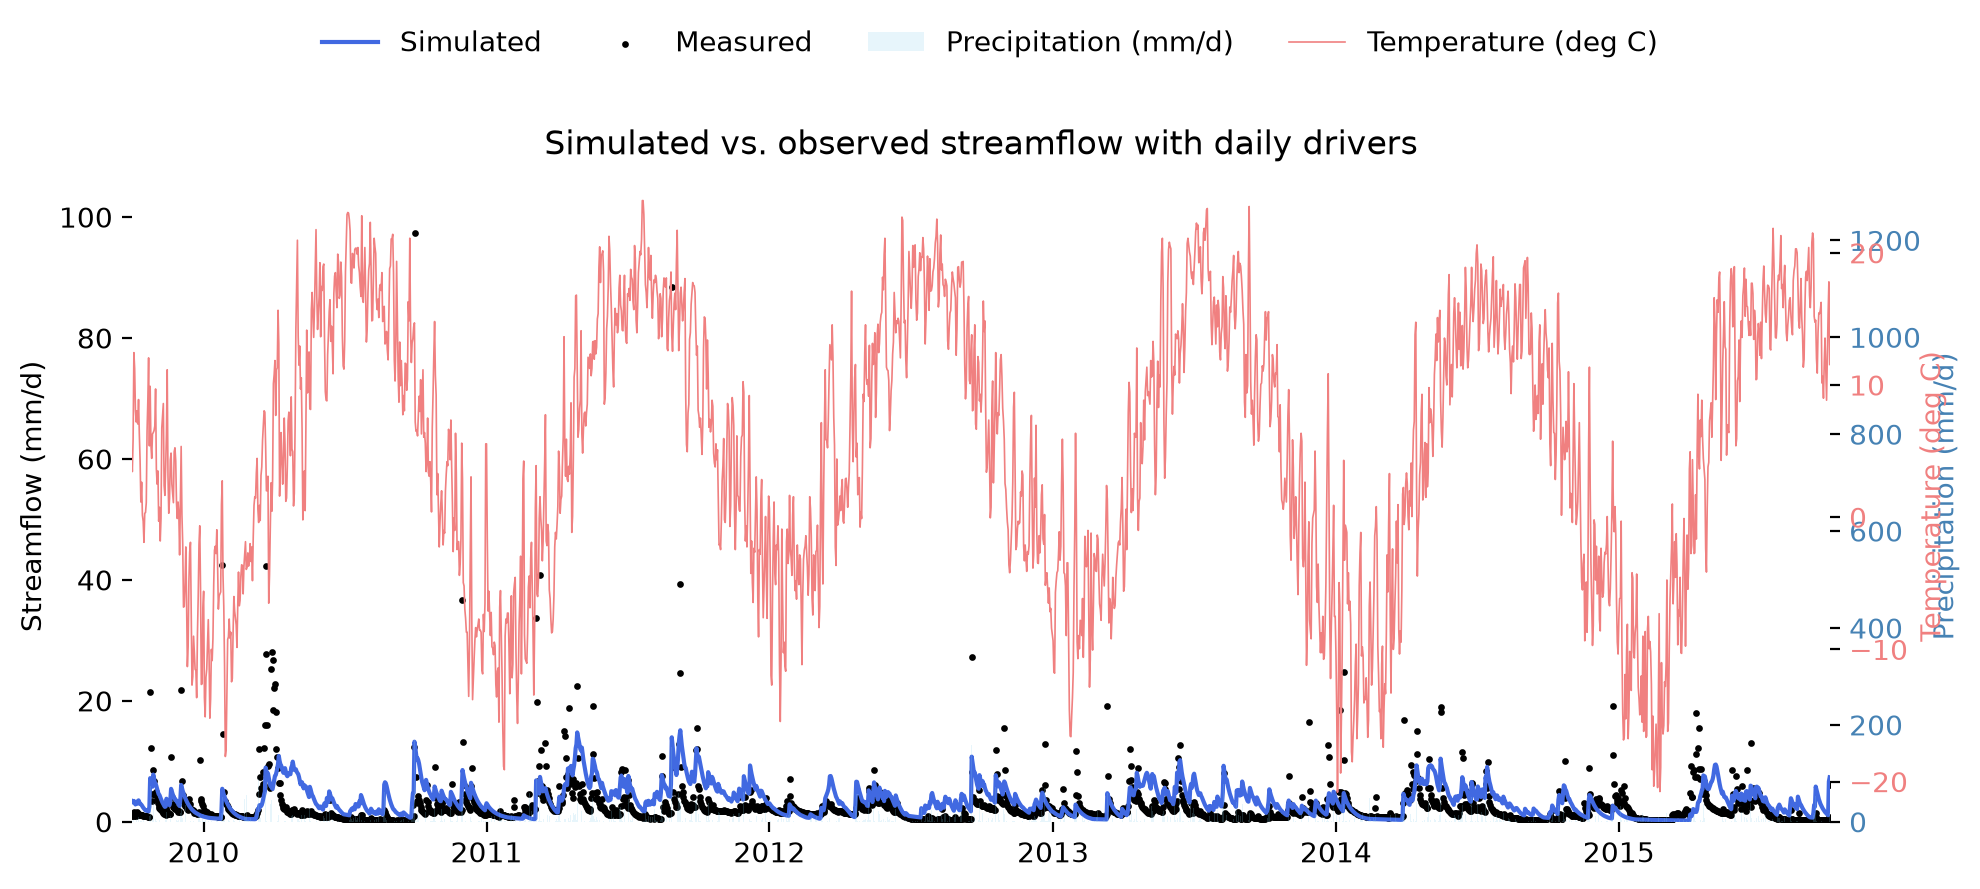

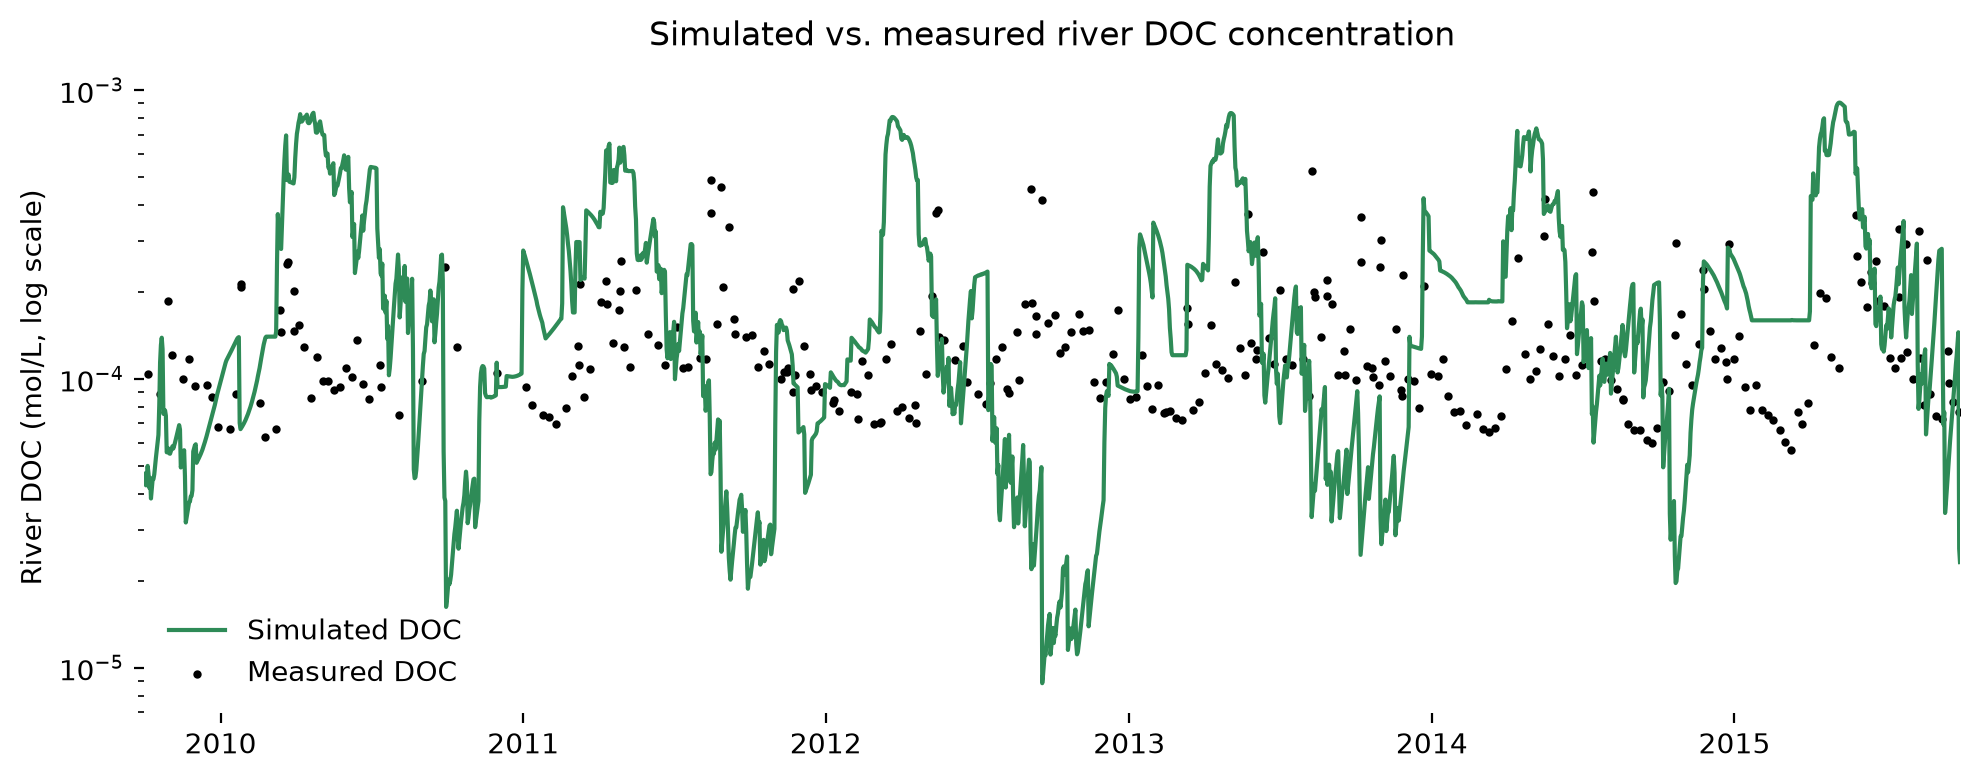

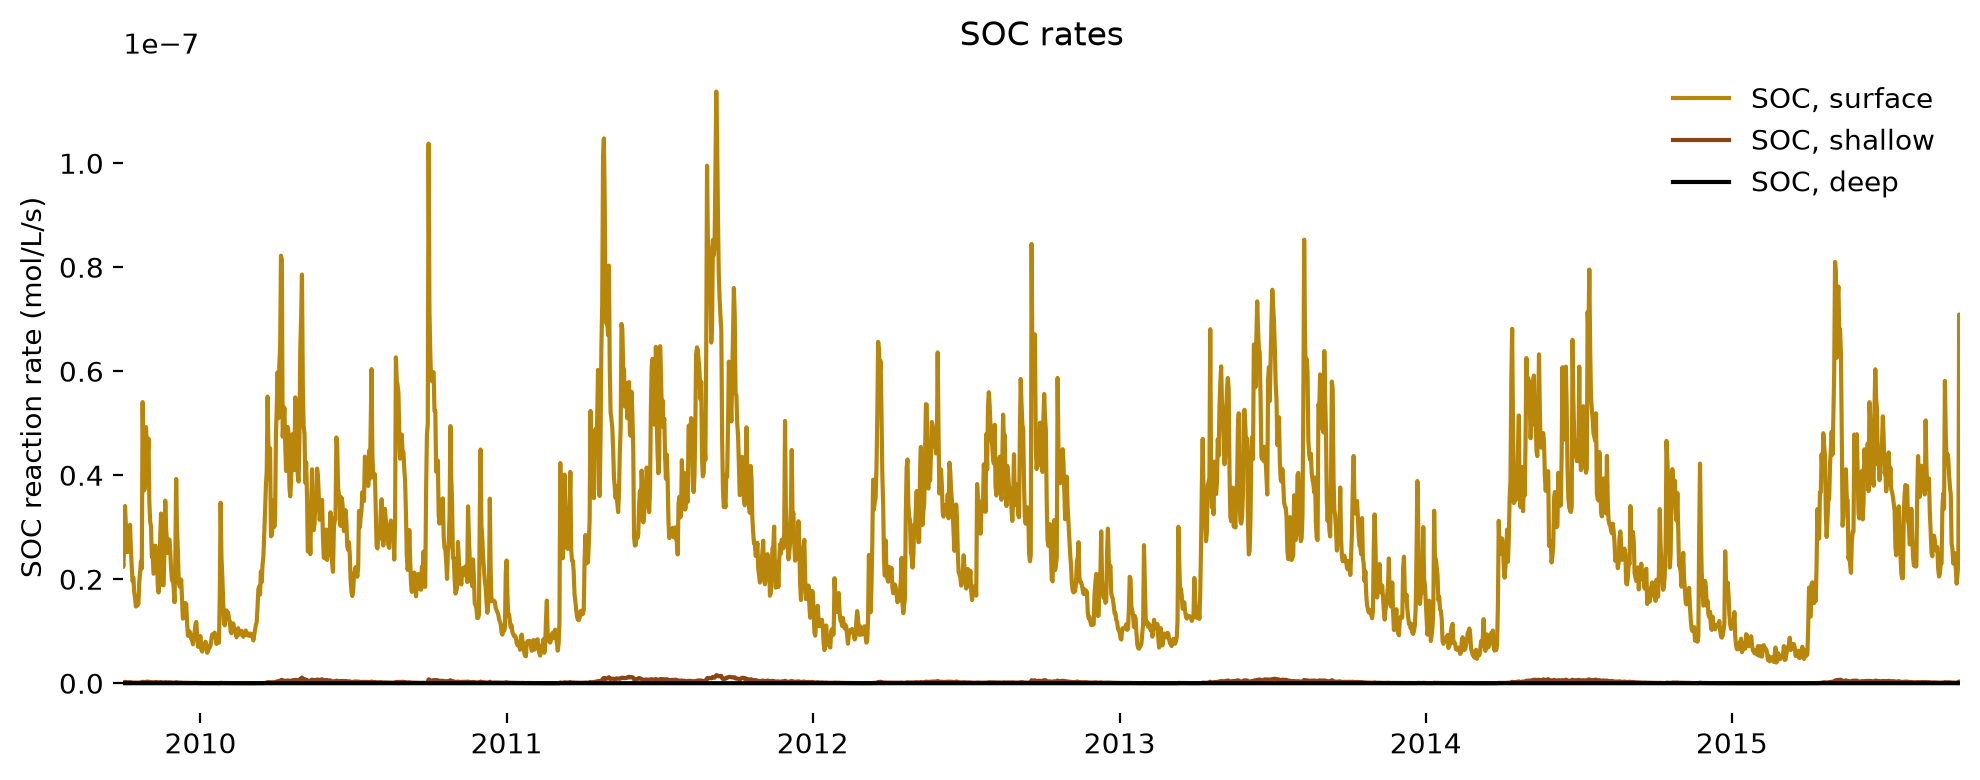

In [9]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

obs_start: pd.Timestamp = meas_streamflow.index[0]
obs_end: pd.Timestamp = meas_streamflow.index[-1]
doc_obs: Series = meas_river_conc["DOC"]

# ---- Panel 1: streamflow vs. precipitation and temperature ---- #
fig: Figure = plt.figure(figsize=(10, 4))
ax: Axes = fig.gca()

ax_ppt: Axes = ax.twinx()
ax_ppt.bar(
    forcing_df.index,
    forcing_df["ppt"],
    width=1.0,
    alpha=0.2,
    color="skyblue",
    label="Precipitation (mm/d)",
)
ax_ppt.set_ylabel("Precipitation (mm/d)", color="steelblue")
ax_ppt.tick_params(axis="y", labelcolor="steelblue")
ax_ppt.set_ylim(0, forcing_df["ppt"].max() * 8)

ax_temp: Axes = ax.twinx()
ax_temp.plot(
    forcing_df.index,
    forcing_df["temp"],
    color="lightcoral",
    linewidth=0.6,
    label="Temperature (deg C)",
)
ax_temp.set_ylabel("Temperature (deg C)", color="lightcoral")
ax_temp.tick_params(axis="y", labelcolor="lightcoral")

ax.plot(
    hydro_df.index, hydro_df["streamflow_sim"], color="royalblue", label="Simulated"
)
ax.scatter(meas_streamflow.index, meas_streamflow, s=2, color="black", label="Measured")
ax.set_xlim(obs_start, obs_end)
ax.set_ylim(0, hydro_df["streamflow_sim"].quantile(0.99) * 10)
ax.set_ylabel("Streamflow (mm/d)")
ax.set_title("Simulated vs. observed streamflow with daily drivers")
fig.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=4)
fig.tight_layout()
plt.show()

# ---- Panel 2: simulated vs. measured river DOC ---- #
fig2: Figure = plt.figure(figsize=(10, 4))
ax2: Axes = fig2.gca()

ax2.plot(rt_df.index, rt_df["DOC_riv"], color="seagreen", label="Simulated DOC")
ax2.scatter(doc_obs.index, doc_obs, s=4, color="black", label="Measured DOC")
ax2.set_yscale("log")
ax2.set_xlim(obs_start, obs_end)
ax2.set_ylabel("River DOC (mol/L, log scale)")
ax2.set_title("Simulated vs. measured river DOC concentration")
ax2.legend()
fig2.tight_layout()
plt.show()

# ---- Panel 3: solid carbon (SOC) depletion in each zone ---- #
fig3: Figure = plt.figure(figsize=(10, 4))
ax3: Axes = fig3.gca()

ax3.plot(
    rt_df.index,
    rt_df["SOC(s)_rate_surface"],
    color="darkgoldenrod",
    label="SOC, surface",
)
ax3.plot(
    rt_df.index, rt_df["SOC(s)_rate_shallow"], color="saddlebrown", label="SOC, shallow"
)
ax3.plot(rt_df.index, rt_df["SOC(s)_rate_deep"], color="black", label="SOC, deep")
ax3.set_xlim(obs_start, obs_end)
ax3.set_ylabel("SOC reaction rate (mol/L/s)")
ax3.set_title("SOC rates")
ax3.legend()
fig3.tight_layout()
plt.show()